# Encoder transform analysis v4 — per-sample local Jacobian, per-column metrics

Differences from `plot_encoder_function3.ipynb`:
1. **6 transforms** (added `learned_gauss` = NWC trained on synthetic Gaussian).
2. **`dist_to_RHT` is unit-norm** (scale-invariant): `‖|J|/‖J‖_F − |J_rht|/‖J_rht‖_F‖_F`.
3. **All metrics from per-sample local Jacobian** `J(x_n) = ∂T/∂x|_{x_n}` via
   `torch.autograd.functional.jacobian` — no empirical-J shortcut.
4. **σ-bin granularity 10** (was 5).
5. **Per-individual-column metrics** — for each of 4096 columns of `W`, compute
   per-sample J on its 256 blocks → metric mean per column → 4096-point plot.

## 0. Setup

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '6'

import sys, json, math, copy as _copy
from pathlib import Path
from collections import OrderedDict

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

notebook_dir = os.path.dirname(os.path.abspath('__file__'))
project_root = os.path.abspath(os.path.join(notebook_dir, '..'))
if project_root not in sys.path: sys.path.append(project_root)
project_root2 = os.path.abspath(os.path.join(os.getcwd(), '..', 'comp_lm_qtip'))
if project_root2 not in sys.path: sys.path.append(project_root2)

import lib.utils as utils
from NWC.models import get_model
from transformers import AutoModelForCausalLM

torch.manual_seed(0); np.random.seed(0)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DTYPE  = torch.float32

FIG_DIR = Path('/home/jgryu/workspace/weight_compression/notebooks/plot/encoder_function4')
FIG_DIR.mkdir(parents=True, exist_ok=True)
print('device', DEVICE, 'fig_dir', FIG_DIR)

W0508 13:16:09.240128 1850840 warnings.py:109] /opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



W0508 13:16:10.458975 1850840 warnings.py:109] /opt/conda/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/opt/conda/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(



W0508 13:16:12.849785 1850840 warnings.py:109] /opt/conda/lib/python3.10/site-packages/compressai/models/video/google.py:353: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @amp.autocast(enabled=False)



Importing from quanto will be deprecated in v4.47. Please install optimum-quanto instrad `pip install optimum-quanto`


W0508 13:16:36.786917 1850840 warnings.py:109] /opt/conda/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(



W0508 13:16:36.788887 1850840 warnings.py:109] /opt/conda/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(



device cuda fig_dir /home/jgryu/workspace/weight_compression/notebooks/plot/encoder_function4


In [2]:
class Config:
    def __init__(self, **e): self.__dict__.update(e)

def load_comp_model(p):
    cfg_p = os.path.join(os.path.dirname(p), 'config.json')
    with open(cfg_p, 'r', encoding='utf-8') as fh:
        cfg = Config(**json.load(fh))
    if cfg.architecture == 'nwc_ql' and not hasattr(cfg, 'Q'): cfg.Q = 4
    if not hasattr(cfg, 'no_layernorm'): cfg.no_layernorm = False
    shift, scale = torch.empty(()), torch.empty(())
    m = get_model(cfg.architecture, cfg, scale=scale, shift=shift)
    m.config = cfg
    ckpt = torch.load(p, weights_only=False)
    scale, shift = torch.ones(1), torch.zeros(1)
    m.load_state_dict(ckpt['state_dict'], strict=False)
    try:    m.scale.copy_(scale); m.shift.copy_(shift)
    except: m.scale = scale; m.shift = shift
    m.eval(); m.update()
    return m

# Original learned (Llama-8B-trained) NWC
NWC_LLAMA_PATH = ('/home/jgryu/workspace/weight_compression/NWC/checkpoint2/nwc_ql/'
                  'block_seq_ql_random_scaler_meta-llama--Meta-Llama-3-8B__col_1024_gaussian_padding.pt/'
                  'M16/lmbda300_rdloss_ql_size16_encdim512_M16_Q4_R0_m0_batch_size2048_total_iter200000_lr0.0001_seed100/'
                  'best_loss_model_loss_5.32101_bpp_5.72603_MSE_0.00289_total_iter_95000.pth.tar')
nwc = load_comp_model(NWC_LLAMA_PATH).to(DEVICE).eval()
BLOCK_DIM = int(nwc.input_size); M_DIM = int(nwc.M); Q_LEVEL = 1
print('NWC (Llama):  input_size=', BLOCK_DIM, 'M=', M_DIM, 'dim_encoder=', nwc.dim_encoder, 'Q=', nwc.Q)

# Gaussian-trained NWC
NWC_GAUSS_PATH = ('/home/jgryu/workspace/weight_compression/NWC/checkpoint/nwc_ql/archive/'
                  'block_seq_ql_random_scaler_synthetic__gaussian_llama8b_col_1024.pt/'
                  'rdloss_ql_size16_encdim512_M16_Q4_R0_m0_batch_size2048_total_iter200000_lr0.0001_seed100/'
                  'lmbda300_/best_loss_model_loss_5.34514_bpp_5.74006_MSE_0.00294_total_iter_47500.pth.tar')
nwc_gauss = load_comp_model(NWC_GAUSS_PATH).to(DEVICE).eval()
print('NWC (Gauss):  loaded, Q=', nwc_gauss.Q)

NWC (Llama):  input_size= 16 M= 16 dim_encoder= 512 Q= 4
NWC (Gauss):  loaded, Q= 4


In [3]:
# Llama-3-8B layer-0 q_proj — ALL blocks, no subsampling
BASE_HF = '/home/jgryu/workspace/weight_compression/Wparam_dataset/hf_model/meta-llama--Meta-Llama-3-8B'
llama = AutoModelForCausalLM.from_pretrained(BASE_HF, torch_dtype='auto', low_cpu_mem_usage=True, local_files_only=True)
W_full = llama.model.layers[0].self_attn.q_proj.weight.detach().float()
W_full = W_full / W_full.std()
print('W_full', tuple(W_full.shape))
del llama; torch.cuda.empty_cache()

X_ALL = W_full.T.reshape(-1, BLOCK_DIM).contiguous().to(DEVICE)
N = X_ALL.shape[0]
sigma_col = W_full.std(dim=0).clamp_min(1e-12)
N_COLS = sigma_col.shape[0]
BLOCKS_PER_COL = W_full.shape[0] // BLOCK_DIM
sigma_per_block = sigma_col.repeat_interleave(BLOCKS_PER_COL)
print(f'X_ALL={tuple(X_ALL.shape)}  N_COLS={N_COLS}  BLOCKS_PER_COL={BLOCKS_PER_COL}')

# scaling: full-matrix per-column
W_col_norm = W_full / sigma_col.unsqueeze(0)
Z_SCALED = W_col_norm.T.reshape(-1, BLOCK_DIM).contiguous().to(DEVICE)

Loading checkpoint shards:   0%|          | 0/7 [00:00<?, ?it/s]

Loading checkpoint shards:  14%|█▍        | 1/7 [00:00<00:03,  1.86it/s]

Loading checkpoint shards:  29%|██▊       | 2/7 [00:00<00:02,  2.42it/s]

Loading checkpoint shards:  43%|████▎     | 3/7 [00:01<00:01,  2.81it/s]

Loading checkpoint shards:  57%|█████▋    | 4/7 [00:01<00:01,  2.82it/s]

...

Loading checkpoint shards:  86%|████████▌ | 6/7 [00:02<00:00,  3.07it/s]

Loading checkpoint shards: 100%|██████████| 7/7 [00:02<00:00,  3.32it/s]

Loading checkpoint shards: 100%|██████████| 7/7 [00:02<00:00,  2.96it/s]

W_full (4096, 4096)


X_ALL=(1048576, 16)  N_COLS=4096  BLOCKS_PER_COL=256


## 1. Six transforms

In [4]:
def make_identity_transform():
    return (lambda x: x.clone())

def hadamard_matrix(n):
    H = torch.tensor([[1.0]])
    while H.shape[0] < n:
        H = torch.cat([torch.cat([H, H], 1), torch.cat([H, -H], 1)], 0)
    return H / math.sqrt(n)

def make_rht_transform(dim=BLOCK_DIM, seed=0):
    g = torch.Generator().manual_seed(seed)
    diag = (torch.randint(0, 2, (dim,), generator=g).mul(2).sub(1)).float().to(DEVICE)
    H = hadamard_matrix(dim).to(DEVICE)
    return (lambda x: (x * diag.unsqueeze(0)) @ H.T)

def make_learned_transform(model, q_level=Q_LEVEL):
    enc = model.g_a
    def f(x):
        x_in = x.unsqueeze(0).contiguous()
        ql = torch.full((1, x.shape[0]), q_level, dtype=torch.long, device=x.device)
        q_embed = model._get_q_embed(q_input=ql, reference=x_in)
        return enc(x_in, q_embed).squeeze(0)
    return f

def make_random_nwc(reference_model, seed=42):
    cfg = _copy.deepcopy(reference_model.config)
    scale, shift = torch.ones(1), torch.zeros(1)
    torch.manual_seed(seed)
    m = get_model(cfg.architecture, cfg, scale=scale, shift=shift)
    try:    m.scale.copy_(scale); m.shift.copy_(shift)
    except: m.scale = scale; m.shift = shift
    return m.eval().to(DEVICE)

nwc_random = make_random_nwc(nwc, seed=42)

TRANSFORMS = OrderedDict()
TRANSFORMS['no_transform']  = make_identity_transform()
TRANSFORMS['rht']           = make_rht_transform(dim=BLOCK_DIM, seed=0)
TRANSFORMS['learned_llama'] = make_learned_transform(nwc, q_level=Q_LEVEL)
TRANSFORMS['learned_gauss'] = make_learned_transform(nwc_gauss, q_level=Q_LEVEL)
TRANSFORMS['random_init']   = make_learned_transform(nwc_random, q_level=Q_LEVEL)
# scaling is positional/stateful — analytical J = g·I per sample, handled separately.
TRANSFORMS['scaling']       = None  # placeholder (handled in compute loop)

names_order = list(TRANSFORMS.keys())
color_map = {
    'no_transform': 'tab:gray',  'scaling':       'tab:olive',
    'rht':          'tab:green', 'learned_llama': 'tab:red',
    'learned_gauss':'tab:blue',  'random_init':   'tab:orange',
}
print('Transforms:', names_order)

Transforms: ['no_transform', 'rht', 'learned_llama', 'learned_gauss', 'random_init', 'scaling']


## 2. Per-sample local Jacobian + 4 metrics (unit-norm dist_to_RHT)

`J(x_n) = ∂T/∂x|_{x=x_n}` computed via `torch.autograd.functional.jacobian`.
Metrics:
- **ortho_rel** = ‖J^T J − αI‖_F / ‖αI‖_F, α = tr(J^T J)/d
- **m2m_med**  = median over rows of `max(|J|)/mean(|J|)`
- **pr_med**   = median over cols of `(Σ|J|)² / Σ J²`
- **dist_to_RHT (unit-norm)** = ‖|J|/‖J‖_F − |J_rht|/‖J_rht‖_F‖_F

In [5]:
def compute_local_jacobian(T, x):
    """T: R^d → R^d.  x: (d,).  Returns J of shape (d, d)."""
    x = x.detach().requires_grad_(True)
    def func(x):
        return T(x)
    return torch.autograd.functional.jacobian(func, x)

def to_single_sample(T):
    def f(x): return T(x.unsqueeze(0)).squeeze(0)
    return f

# RHT reference J (constant; used by dist_to_RHT)
g = torch.Generator().manual_seed(0)
_diag_rht = (torch.randint(0, 2, (BLOCK_DIM,), generator=g).mul(2).sub(1)).float().to(DEVICE)
_H_rht = hadamard_matrix(BLOCK_DIM).to(DEVICE)
J_rht_ref = torch.diag(_diag_rht) @ _H_rht.T              # (d, d) — analytical RHT J

@torch.no_grad()
def metrics_array_for_J(J_batch, J_rht=J_rht_ref):
    """J_batch: (B, D, D) → (B, 4) tensor of [ortho_rel, m2m_med, pr_med, dist_to_RHT_unit]."""
    B, D, _ = J_batch.shape
    eye = torch.eye(D, device=J_batch.device, dtype=J_batch.dtype).unsqueeze(0)
    G = J_batch.transpose(-1, -2) @ J_batch
    alpha = G.diagonal(dim1=-2, dim2=-1).sum(dim=-1) / D
    diff  = G - alpha.view(B, 1, 1) * eye
    norm_diff   = torch.linalg.norm(diff.reshape(B, -1), dim=-1)
    norm_alphaI = alpha.abs() * math.sqrt(D)
    ortho_rel = norm_diff / norm_alphaI.clamp_min(1e-12)
    A = J_batch.abs()
    row_max  = A.max(dim=-1).values
    row_mean = A.mean(dim=-1).clamp_min(1e-12)
    m2m_med  = (row_max / row_mean).median(dim=-1).values
    col_sum  = A.sum(dim=-2)
    col_l2sq = (A ** 2).sum(dim=-2).clamp_min(1e-12)
    pr_med   = ((col_sum ** 2) / col_l2sq).median(dim=-1).values
    # unit-norm dist_to_RHT
    norm_J   = torch.linalg.norm(J_batch.reshape(B, -1), dim=-1).clamp_min(1e-12)
    norm_R   = torch.linalg.norm(J_rht).clamp_min(1e-12)
    A_unit   = A / norm_J.view(B, 1, 1)
    R_unit   = J_rht.abs() / norm_R
    d_unit   = torch.linalg.norm((A_unit - R_unit.unsqueeze(0)).reshape(B, -1), dim=-1)
    return torch.stack([ortho_rel, m2m_med, pr_med, d_unit], dim=-1)

print('helpers ready (unit-norm dist_to_RHT)')

helpers ready (unit-norm dist_to_RHT)


## 3. Per-column metric computation

For each of the **4096 columns**, take `N_PER_COL` randomly-selected blocks (out of 256
blocks/col), compute per-sample J on each, derive 4 metrics per sample.  Aggregate to
column level (mean and std).

In [6]:
# 3a. Per-column compute.  For 6 transforms × 4096 cols × N_PER_COL blocks
# we use autograd-loop (slow but reliable).  Subsample N_PER_COL=8 per column (8 × 4096 = 32768
# samples per transform).
N_PER_COL = 8

eye_d = torch.eye(BLOCK_DIM, device=DEVICE)
torch.manual_seed(0)

# Choose N_PER_COL block indices PER column (consistent across transforms)
sub_within_col = torch.stack([torch.randperm(BLOCKS_PER_COL)[:N_PER_COL]
                              for _ in range(N_COLS)], dim=0)              # (N_COLS, N_PER_COL)
# Convert to global block indices: global_idx[c, k] = c * BLOCKS_PER_COL + sub_within_col[c, k]
global_idx = (torch.arange(N_COLS).unsqueeze(1) * BLOCKS_PER_COL + sub_within_col).to(DEVICE)
flat_idx   = global_idx.reshape(-1)                                        # (N_COLS * N_PER_COL,)
X_sub      = X_ALL[flat_idx]                                               # (N_COLS*N_PER_COL, 16)
sigma_sub  = sigma_per_block.to(DEVICE)[flat_idx]                          # (N_COLS*N_PER_COL,)
print(f'X_sub: {tuple(X_sub.shape)}  sigma_sub: {tuple(sigma_sub.shape)}')

# Per-transform compute J_batch
import time
J_BATCH = {}
N_TOT = X_sub.shape[0]
for tname in names_order:
    t0 = time.time()
    if tname == 'no_transform':
        J_BATCH[tname] = eye_d.unsqueeze(0).expand(N_TOT, -1, -1).contiguous()
    elif tname == 'scaling':
        g_n = (1.0 / sigma_sub)
        J_BATCH[tname] = g_n.view(-1, 1, 1) * eye_d.unsqueeze(0)
    else:
        tf = TRANSFORMS[tname]
        f_single = to_single_sample(tf)
        J_list = []
        for i in range(N_TOT):
            J_list.append(compute_local_jacobian(f_single, X_sub[i]).detach())
        J_BATCH[tname] = torch.stack(J_list, 0)
    elapsed = time.time() - t0
    print(f'  {tname:14s}  J_batch shape={tuple(J_BATCH[tname].shape)}  ({elapsed:.1f}s)')

X_sub: (32768, 16)  sigma_sub: (32768,)
  no_transform    J_batch shape=(32768, 16, 16)  (0.0s)


  rht             J_batch shape=(32768, 16, 16)  (90.2s)


  learned_llama   J_batch shape=(32768, 16, 16)  (322.7s)


  learned_gauss   J_batch shape=(32768, 16, 16)  (321.4s)


  random_init     J_batch shape=(32768, 16, 16)  (323.9s)
  scaling         J_batch shape=(32768, 16, 16)  (0.1s)


In [7]:
# 3b. Compute metrics per sample, then aggregate to per-column statistics.
PER_SAMPLE = {}      # tname -> (N_TOT, 4)
PER_COL    = {}      # tname -> dict with 'mean' (N_COLS, 4) and 'std' (N_COLS, 4)

for tname in names_order:
    metrics = metrics_array_for_J(J_BATCH[tname], J_rht_ref)               # (N_TOT, 4)
    PER_SAMPLE[tname] = metrics.cpu().numpy()
    metrics_by_col = metrics.reshape(N_COLS, N_PER_COL, 4)                 # (4096, N_PER_COL, 4)
    PER_COL[tname] = {
        'mean': metrics_by_col.mean(dim=1).cpu().numpy(),                  # (4096, 4)
        'std':  metrics_by_col.std(dim=1).cpu().numpy(),                   # (4096, 4)
    }
    m = PER_SAMPLE[tname]
    print(f'{tname:14s}  global mean: ortho={m[:,0].mean():.4f}±{m[:,0].std():.4f}  '
          f'm2m={m[:,1].mean():.4f}±{m[:,1].std():.4f}  '
          f'pr={m[:,2].mean():.4f}±{m[:,2].std():.4f}  '
          f'dist={m[:,3].mean():.4f}±{m[:,3].std():.4f}')

no_transform    global mean: ortho=0.0000±0.0000  m2m=16.0000±0.0000  pr=1.0000±0.0000  dist=1.2247±0.0000
rht             global mean: ortho=0.0000±0.0000  m2m=1.0000±0.0000  pr=16.0000±0.0000  dist=0.0000±0.0000
learned_llama   global mean: ortho=0.0194±0.0144  m2m=3.9793±0.0197  pr=7.5340±0.0505  dist=0.7925±0.0014
learned_gauss   global mean: ortho=0.0317±0.0398  m2m=2.5694±0.0205  pr=10.7350±0.0493  dist=0.6046±0.0010
random_init     global mean: ortho=1.5099±0.1500  m2m=2.4682±0.1303  pr=10.7193±0.3539  dist=0.6331±0.0207
scaling         global mean: ortho=0.0000±0.0000  m2m=16.0000±0.0000  pr=1.0000±0.0000  dist=1.2247±0.0000


## 4. Plot — per-sample metric distributions (overall)

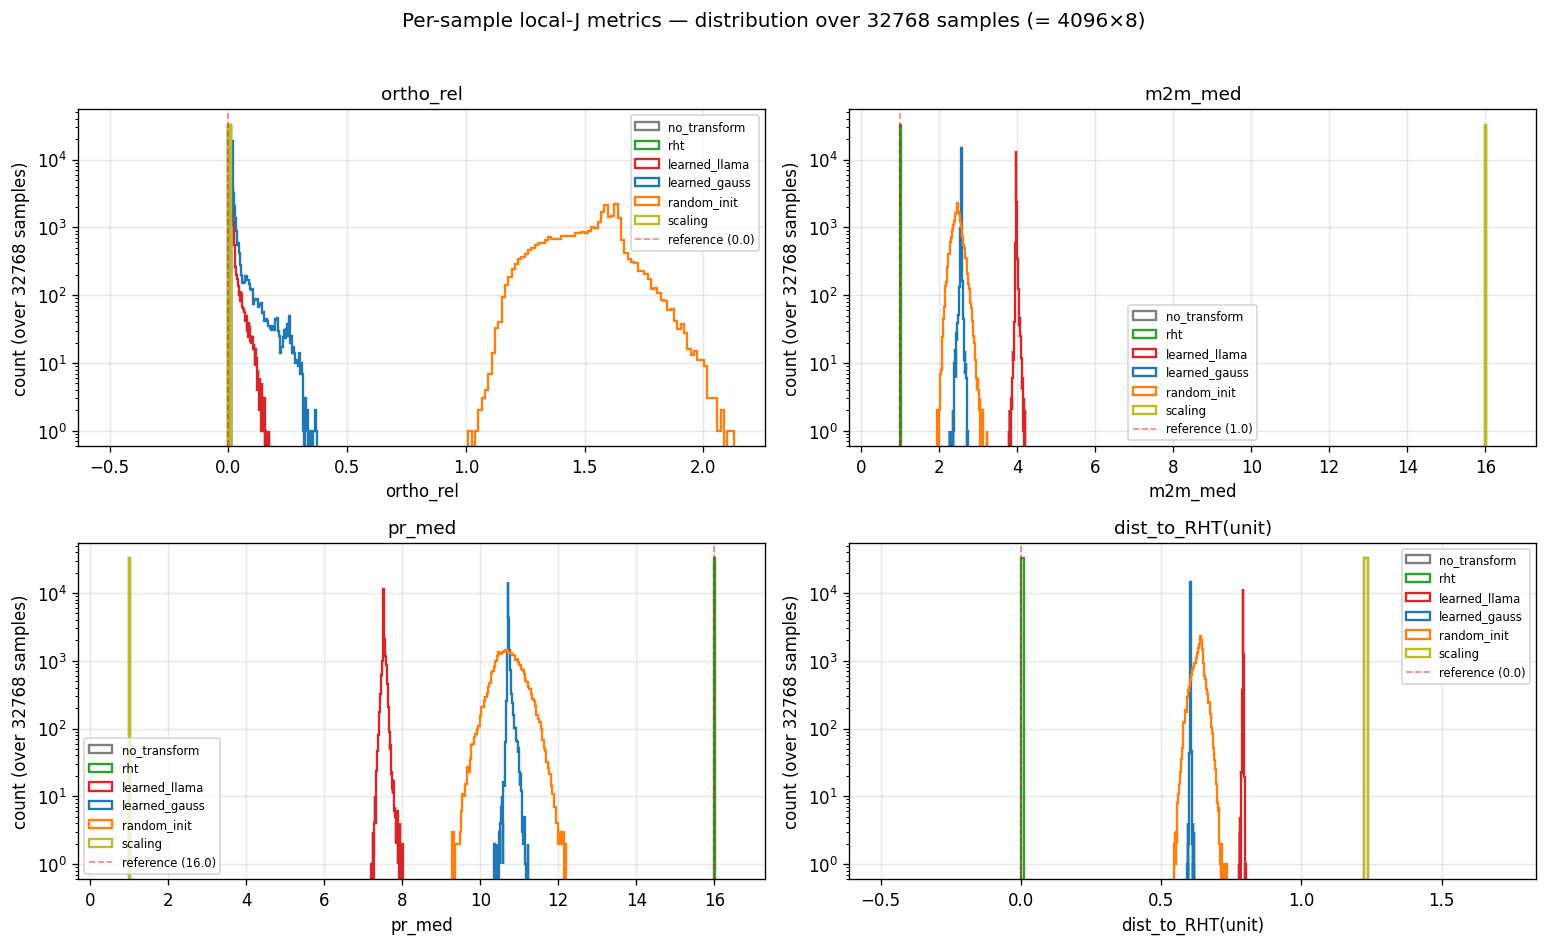

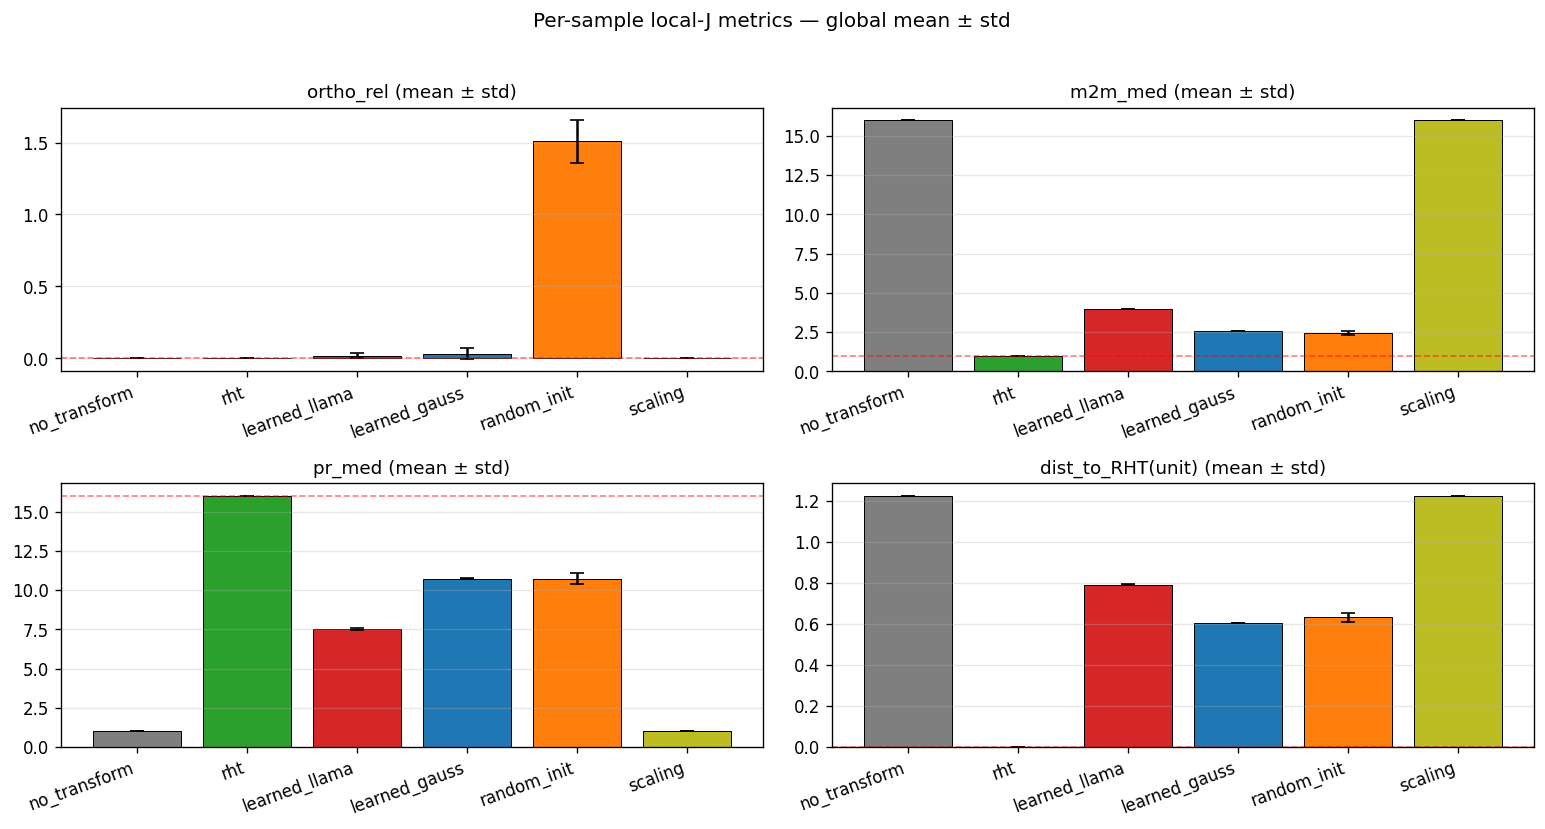

    transform  ortho_rel_mean  m2m_med_mean  pr_med_mean  dist_to_RHT(unit)_mean  ortho_rel_std  m2m_med_std  pr_med_std  dist_to_RHT(unit)_std
 no_transform          0.0000       16.0000       1.0000                  1.2247         0.0000       0.0000      0.0000                 0.0000
          rht          0.0000        1.0000      16.0000                  0.0000         0.0000       0.0000      0.0000                 0.0000
learned_llama          0.0194        3.9793       7.5340                  0.7925         0.0144       0.0197      0.0505                 0.0014
learned_gauss          0.0317        2.5694      10.7350                  0.6046         0.0398       0.0205      0.0493                 0.0010
  random_init          1.5099        2.4682      10.7193                  0.6331         0.1500       0.1303      0.3539                 0.0207
      scaling          0.0000       16.0000       1.0000                  1.2247         0.0000       0.0000      0.0000                

In [8]:
metric_cols = ['ortho_rel', 'm2m_med', 'pr_med', 'dist_to_RHT(unit)']
metric_refs = [0.0, 1.0, 16.0, 0.0]

fig, axes = plt.subplots(2, 2, figsize=(13, 8), dpi=120)
for idx, (ax, mname, ref) in enumerate(zip(axes.flatten(), metric_cols, metric_refs)):
    for tname in names_order:
        vals = PER_SAMPLE[tname][:, idx]
        ax.hist(vals, bins=80, histtype='step', linewidth=1.4,
                color=color_map.get(tname, 'C0'), label=tname)
    ax.axvline(ref, color='red', ls='--', alpha=0.5, linewidth=1.0,
               label=f'reference ({ref})')
    ax.set_xlabel(mname); ax.set_ylabel(f'count (over {N_TOT} samples)')
    ax.set_title(mname, fontsize=11); ax.set_yscale('log')
    ax.grid(True, alpha=0.3); ax.legend(fontsize=7)
fig.suptitle(f'Per-sample local-J metrics — distribution over {N_TOT} samples (= {N_COLS}×{N_PER_COL})',
             fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(FIG_DIR / 'fig01_per_sample_hist.png'); plt.show()

# Mean ± std bar chart
df_global = pd.DataFrame([{
    'transform': t,
    **{f'{c}_mean': float(PER_SAMPLE[t][:, i].mean()) for i, c in enumerate(metric_cols)},
    **{f'{c}_std':  float(PER_SAMPLE[t][:, i].std())  for i, c in enumerate(metric_cols)},
} for t in names_order])
df_global.to_csv(FIG_DIR / 'fig01_global_summary.csv', index=False)

fig, axes = plt.subplots(2, 2, figsize=(13, 7), dpi=120)
xs = np.arange(len(names_order))
for ax, mname, ref in zip(axes.flatten(), metric_cols, metric_refs):
    means = df_global[f'{mname}_mean'].values
    stds  = df_global[f'{mname}_std'].values
    ax.bar(xs, means, yerr=stds, capsize=4,
           color=[color_map.get(t, 'C0') for t in names_order],
           edgecolor='black', linewidth=0.6)
    ax.axhline(ref, color='red', ls='--', alpha=0.5, linewidth=1.0)
    ax.set_xticks(xs); ax.set_xticklabels(names_order, rotation=20, ha='right')
    ax.set_title(f'{mname} (mean ± std)', fontsize=11)
    ax.grid(True, axis='y', alpha=0.3)
fig.suptitle(f'Per-sample local-J metrics — global mean ± std', fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(FIG_DIR / 'fig02_global_meanstd.png'); plt.show()
print(df_global.round(4).to_string(index=False))

## 5. Σ-bin analysis (10 bins by σ_c)

In [9]:
N_BINS = 10
qs    = torch.linspace(0, 1, N_BINS + 1)
edges = torch.quantile(sigma_col, qs).numpy()                              # (N_BINS+1,)
bound = torch.tensor(edges[1:-1], dtype=sigma_col.dtype)
col_bin_idx = torch.bucketize(sigma_col, bound)                            # (N_COLS,)
print(f'σ_c quantile edges: {[f"{e:.3f}" for e in edges]}')

# Aggregate per-column means by σ-bin
rows = []
for tname in names_order:
    means = PER_COL[tname]['mean']                                         # (N_COLS, 4)
    for b in range(N_BINS):
        mask = (col_bin_idx == b).numpy()
        if not mask.any(): continue
        s_mid = float(sigma_col[col_bin_idx == b].median())
        sub = means[mask]                                                  # (n_cols_in_bin, 4)
        row = {'transform': tname, 'bin': b, 'sigma_mid': s_mid, 'n_cols': int(mask.sum())}
        for i, c in enumerate(metric_cols):
            row[f'{c}_mean'] = float(sub[:, i].mean())
            row[f'{c}_std']  = float(sub[:, i].std())
        rows.append(row)
df_bin = pd.DataFrame(rows)
df_bin.to_csv(FIG_DIR / 'fig03_sigma_bin10_metrics.csv', index=False)
print(f'\n{df_bin[df_bin["transform"]=="learned_llama"][["bin","sigma_mid","ortho_rel_mean","pr_med_mean","dist_to_RHT(unit)_mean"]].round(4).to_string(index=False)}')

σ_c quantile edges: ['0.007', '0.017', '0.053', '0.146', '0.665', '0.780', '0.882', '1.051', '1.419', '1.611', '4.554']

 bin  sigma_mid  ortho_rel_mean  pr_med_mean  dist_to_RHT(unit)_mean
   0     0.0132          0.0130       7.5223                  0.7930
   1     0.0264          0.0130       7.5225                  0.7930
   2     0.0893          0.0130       7.5243                  0.7930
   3     0.2487          0.0144       7.5258                  0.7929
   4     0.7255          0.0176       7.5281                  0.7927
   5     0.8271          0.0189       7.5303                  0.7926
   6     0.9440          0.0204       7.5324                  0.7925
   7     1.2227          0.0240       7.5416                  0.7921
   8     1.5130          0.0277       7.5476                  0.7917
   9     1.7995          0.0315       7.5648                  0.7910


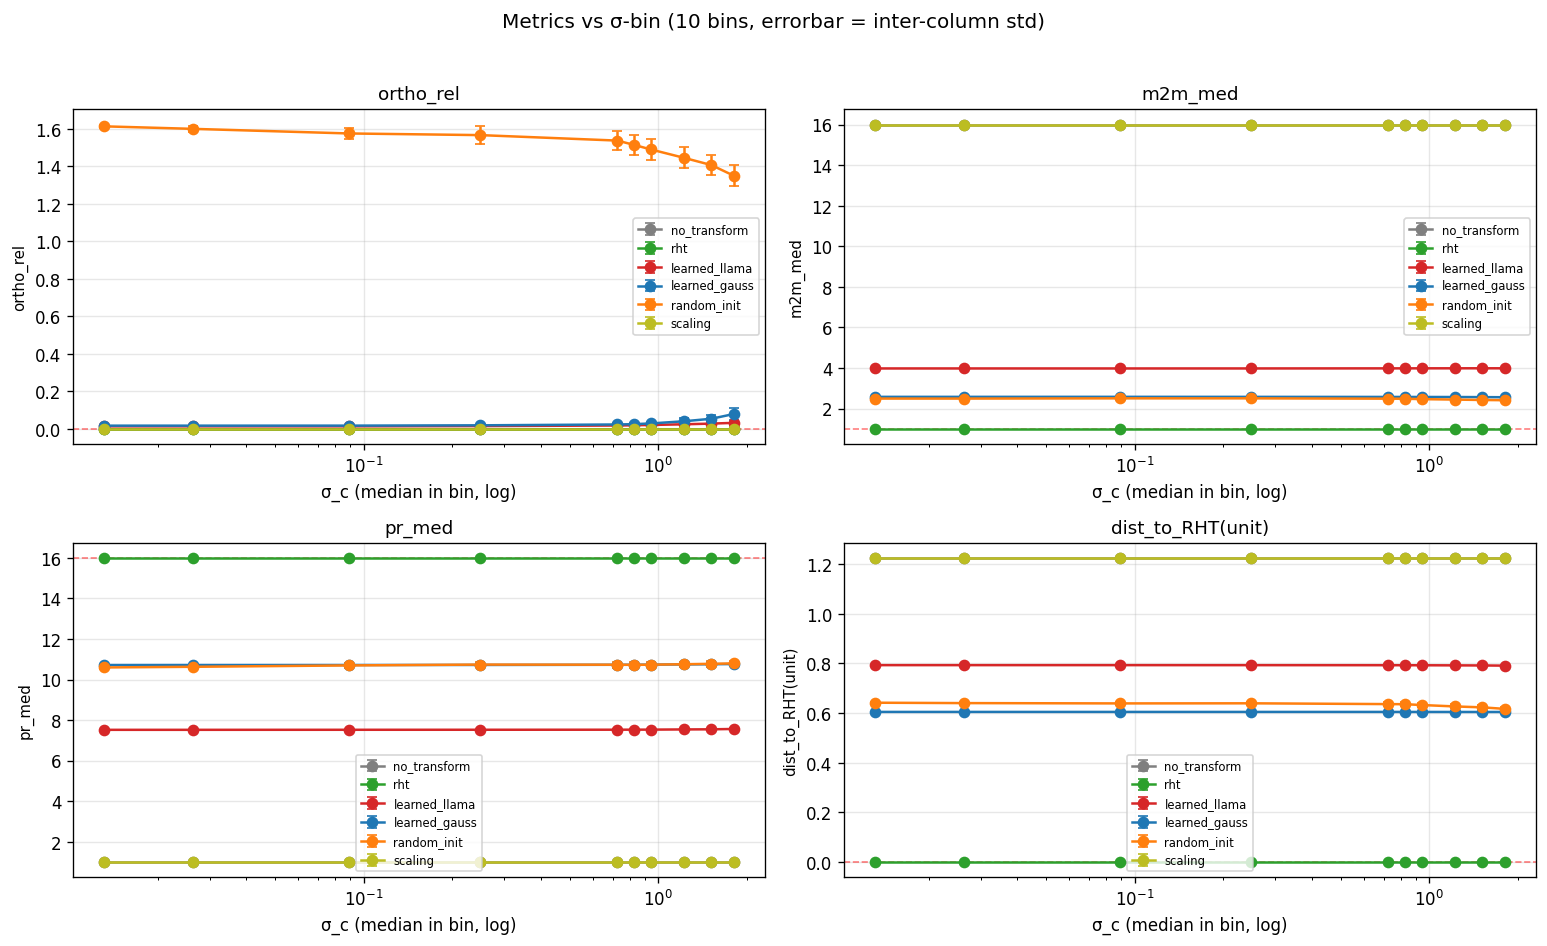

In [10]:
# Plot — 4 metrics vs σ-bin (10 bins), one line per transform, errorbar = within-bin per-column std.
fig, axes = plt.subplots(2, 2, figsize=(13, 8), dpi=120)
for ax, mname, ref in zip(axes.flatten(), metric_cols, metric_refs):
    for tname in names_order:
        sub = df_bin[df_bin['transform'] == tname].sort_values('sigma_mid')
        if len(sub) == 0: continue
        ax.errorbar(sub['sigma_mid'], sub[f'{mname}_mean'], yerr=sub[f'{mname}_std'],
                    marker='o', linewidth=1.5, capsize=3,
                    color=color_map.get(tname, 'C0'), label=tname)
    ax.axhline(ref, color='red', ls='--', alpha=0.5, linewidth=1.0)
    ax.set_xscale('log')
    ax.set_xlabel('σ_c (median in bin, log)')
    ax.set_ylabel(mname, fontsize=9); ax.set_title(mname, fontsize=11)
    ax.grid(True, alpha=0.3); ax.legend(fontsize=7)
fig.suptitle(f'Metrics vs σ-bin ({N_BINS} bins, errorbar = inter-column std)', fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(FIG_DIR / 'fig03_sigma_bin10.png'); plt.show()

## 6. Per-column metrics (4096 columns, sorted by σ_c)

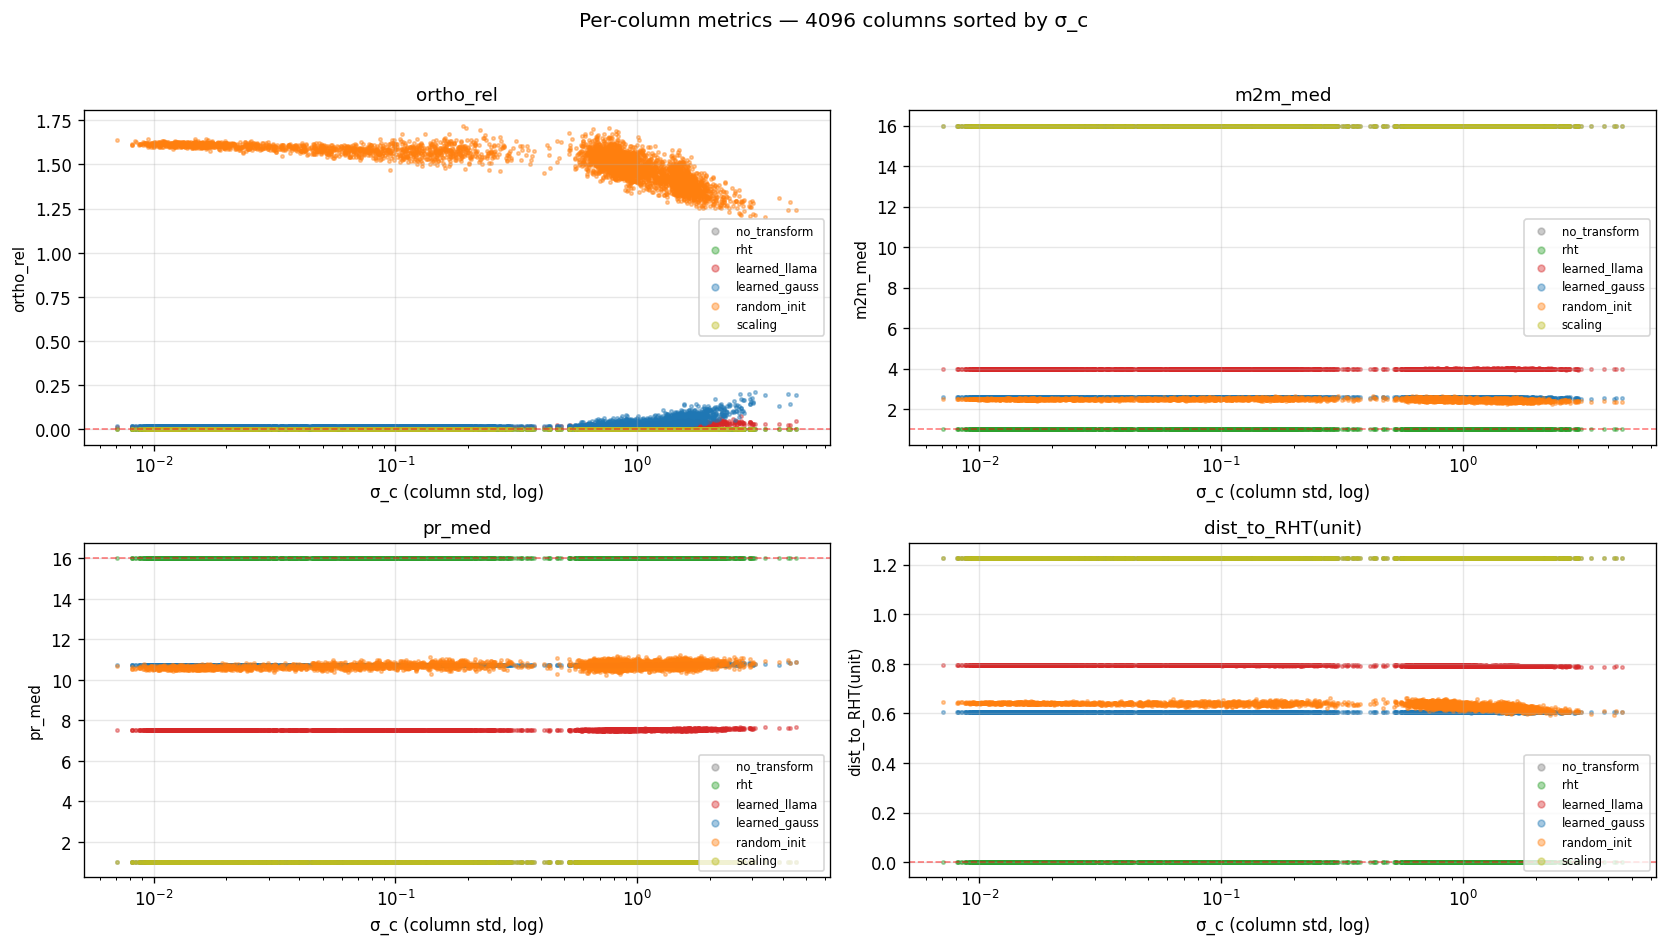

In [11]:
# Sort columns by σ
sort_idx = torch.argsort(sigma_col).numpy()                                # (N_COLS,) ascending
sorted_sigma = sigma_col.numpy()[sort_idx]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), dpi=120)
for idx, (ax, mname, ref) in enumerate(zip(axes.flatten(), metric_cols, metric_refs)):
    for tname in names_order:
        vals = PER_COL[tname]['mean'][:, idx][sort_idx]                    # (N_COLS,) sorted
        ax.scatter(sorted_sigma, vals, s=4, alpha=0.4,
                   color=color_map.get(tname, 'C0'), label=tname)
    ax.axhline(ref, color='red', ls='--', alpha=0.5, linewidth=1.0)
    ax.set_xscale('log')
    ax.set_xlabel('σ_c (column std, log)')
    ax.set_ylabel(mname, fontsize=9); ax.set_title(mname, fontsize=11)
    ax.grid(True, alpha=0.3); ax.legend(fontsize=7, markerscale=2)
fig.suptitle(f'Per-column metrics — {N_COLS} columns sorted by σ_c', fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(FIG_DIR / 'fig04_per_col_scatter.png'); plt.show()

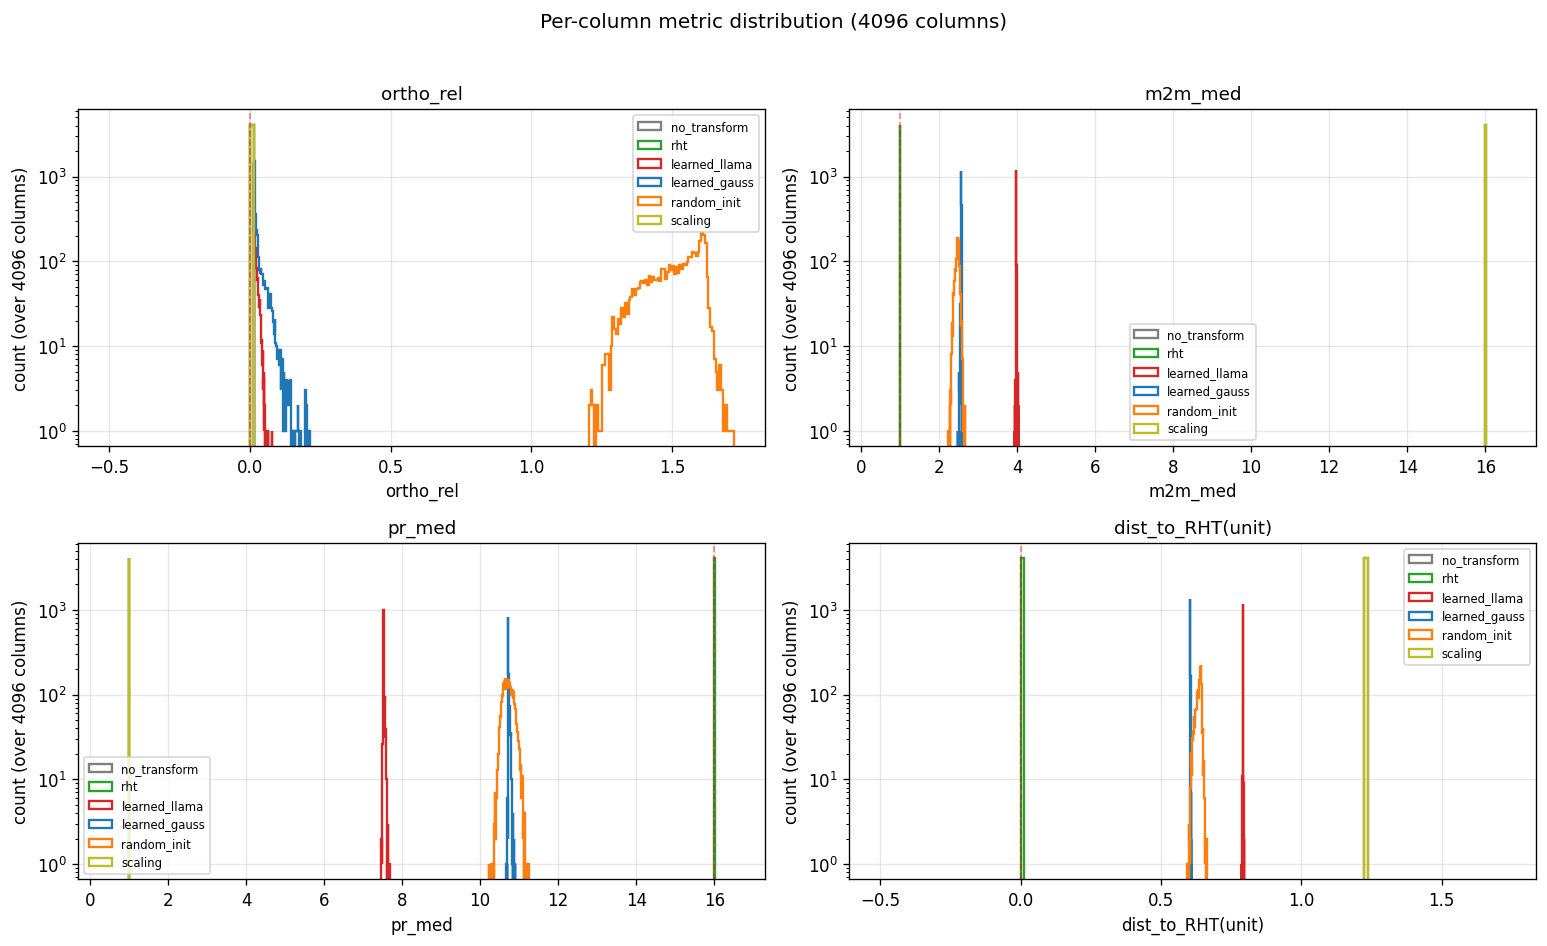

Saved per-column metrics: /home/jgryu/workspace/weight_compression/notebooks/plot/encoder_function4/fig05_per_col_metrics.csv


In [12]:
# Per-column distribution histogram (4096 column-mean values per metric)
fig, axes = plt.subplots(2, 2, figsize=(13, 8), dpi=120)
for idx, (ax, mname, ref) in enumerate(zip(axes.flatten(), metric_cols, metric_refs)):
    for tname in names_order:
        vals = PER_COL[tname]['mean'][:, idx]
        ax.hist(vals, bins=80, histtype='step', linewidth=1.4,
                color=color_map.get(tname, 'C0'), label=tname)
    ax.axvline(ref, color='red', ls='--', alpha=0.5, linewidth=1.0)
    ax.set_xlabel(mname); ax.set_ylabel(f'count (over {N_COLS} columns)')
    ax.set_title(mname, fontsize=11); ax.set_yscale('log')
    ax.grid(True, alpha=0.3); ax.legend(fontsize=7)
fig.suptitle(f'Per-column metric distribution ({N_COLS} columns)', fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(FIG_DIR / 'fig05_per_col_hist.png'); plt.show()

# Save per-column data (compact)
import csv
with open(FIG_DIR / 'fig05_per_col_metrics.csv', 'w', newline='') as f:
    w = csv.writer(f)
    header = ['col', 'sigma'] + [f'{t}_{c}_{stat}' for t in names_order
                                  for c in metric_cols for stat in ['mean','std']]
    w.writerow(header)
    sigma_np = sigma_col.numpy()
    for c in range(N_COLS):
        row = [c, float(sigma_np[c])]
        for t in names_order:
            for i in range(4):
                row.append(float(PER_COL[t]['mean'][c, i]))
                row.append(float(PER_COL[t]['std'][c, i]))
        w.writerow(row)
print(f'Saved per-column metrics: {FIG_DIR}/fig05_per_col_metrics.csv')

## 7. Norm-amplification — `‖z − ž‖ / ‖x − x̄‖` vs `‖x − x̄‖`

For each transform, scatter shows how output-norm **scales** with input-norm.

- **Linear orthogonal** (rht): horizontal line at constant ratio (= 1 if energy-preserving).
- **Linear scaling** (scaling): one g_n per sample → ratio depends on which column the
  sample came from.
- **Identity**: ratio = 1 (constant).
- **Nonlinear** (learned, random_init): ratio varies with input magnitude — small inputs
  may be amplified more (or less), revealing the encoder's local stretch behavior.

In [13]:
# 7a. For all 1M blocks, compute (x_size, z_size, ratio) per sample for each transform.
# Apply transform in batches; centroid is shared (computed once per transform).
import time

EPS = 1e-12
X_mean = X_ALL.mean(dim=0, keepdim=True)                                   # (1, 16)

# Subsample for plotting (32K already used for Jacobian; reuse so figures are consistent)
torch.manual_seed(0)
N_PLOT = 65536
plot_idx = torch.randperm(N, device=DEVICE)[:N_PLOT]
X_plot   = X_ALL[plot_idx]                                                 # (N_PLOT, 16)
Xc_plot  = X_plot - X_mean                                                 # use full-dataset mean
x_size   = torch.linalg.norm(Xc_plot, dim=-1).cpu().numpy()                # (N_PLOT,)
sigma_plot = sigma_per_block.to(DEVICE)[plot_idx].cpu().numpy()            # (N_PLOT,) for color

NORM_DATA = {}                                                             # tname -> dict
for tname in names_order:
    t0 = time.time()
    if tname == 'no_transform':
        Z_plot = X_plot.clone()
    elif tname == 'scaling':
        # full-matrix per-column scaling: J = g·I, so Z = g·X
        g_n = (1.0 / sigma_per_block.to(DEVICE)[plot_idx]).view(-1, 1)
        Z_plot = X_plot * g_n
    else:
        tf = TRANSFORMS[tname]
        out = []
        bs = 4096
        with torch.no_grad():
            for i in range(0, N_PLOT, bs):
                out.append(tf(X_plot[i:i+bs]))
        Z_plot = torch.cat(out, 0)
    Z_mean = Z_plot.mean(dim=0, keepdim=True)
    Zc = Z_plot - Z_mean
    z_size = torch.linalg.norm(Zc, dim=-1).cpu().numpy()
    ratio  = z_size / (x_size + EPS)
    NORM_DATA[tname] = {'x_size': x_size, 'z_size': z_size, 'ratio': ratio,
                        'sigma': sigma_plot}
    print(f'{tname:14s}  x_size mean={x_size.mean():.3f}  z_size mean={z_size.mean():.3f}  '
          f'ratio mean={ratio.mean():.3f}±{ratio.std():.3f}  ({time.time()-t0:.1f}s)')

no_transform    x_size mean=2.787  z_size mean=2.788  ratio mean=1.026±0.097  (0.0s)
rht             x_size mean=2.787  z_size mean=2.788  ratio mean=1.026±0.097  (0.0s)
learned_llama   x_size mean=2.787  z_size mean=13.228  ratio mean=5.058±0.972  (0.0s)
learned_gauss   x_size mean=2.787  z_size mean=12.963  ratio mean=4.955±0.832  (0.0s)


random_init     x_size mean=2.787  z_size mean=16.339  ratio mean=52.154±102.413  (0.0s)
scaling         x_size mean=2.787  z_size mean=3.547  ratio mean=13.562±24.749  (0.0s)


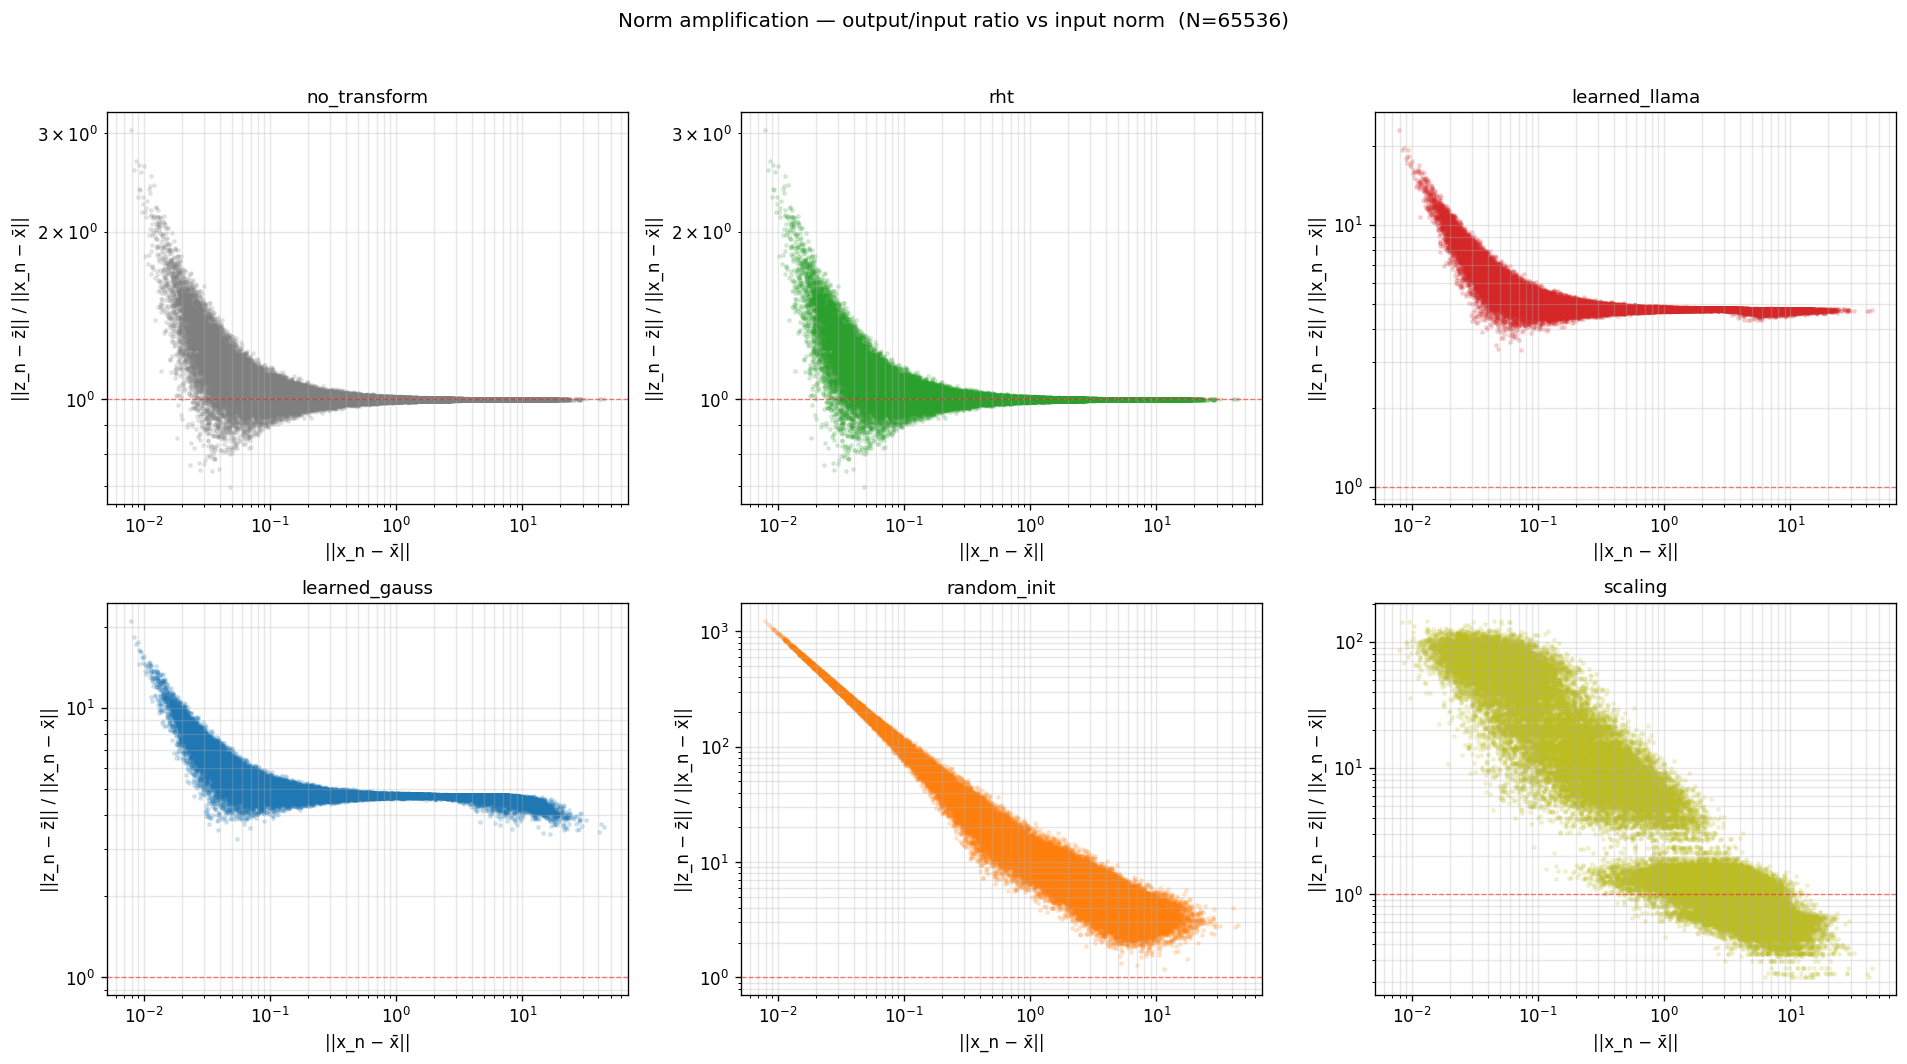

In [14]:
# 7b. Plot — scatter `ratio vs x_size`, 1 panel per transform.
fig, axes = plt.subplots(2, 3, figsize=(16, 9), dpi=120)
axes = axes.flatten()
for ax, tname in zip(axes, names_order):
    d = NORM_DATA[tname]
    ax.scatter(d['x_size'], d['ratio'], s=4, alpha=0.15,
               color=color_map.get(tname, 'C0'))
    # reference line: ratio=1 (energy-preserving)
    ax.axhline(1.0, color='red', ls='--', alpha=0.5, linewidth=0.8)
    ax.set_xlabel('||x_n − x̄||')
    ax.set_ylabel('||z_n − z̄|| / ||x_n − x̄||')
    ax.set_title(tname, fontsize=11)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True, which='both', alpha=0.3)
fig.suptitle(f'Norm amplification — output/input ratio vs input norm  (N={N_PLOT})',
             fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(FIG_DIR / 'fig06_norm_amp_scatter.png'); plt.show()

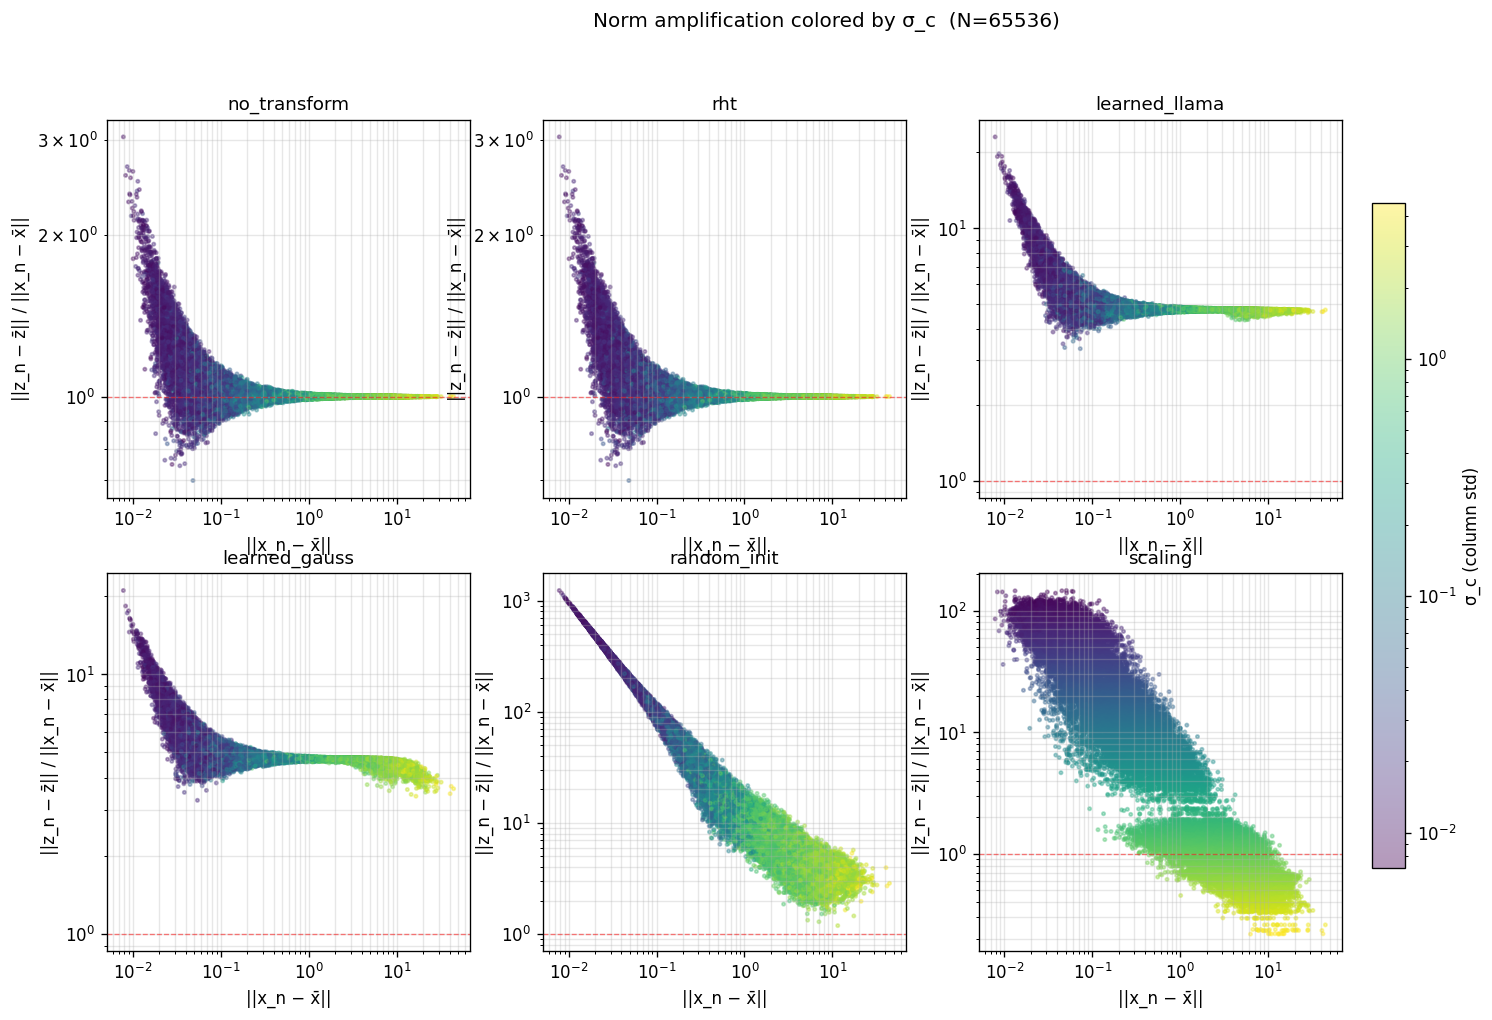

In [15]:
# 7c. Same scatter, points colored by σ_c (column scale of the source block).
fig, axes = plt.subplots(2, 3, figsize=(16, 9), dpi=120)
axes = axes.flatten()
import matplotlib.colors as mcolors
norm_color = mcolors.LogNorm(vmin=float(sigma_col.min()), vmax=float(sigma_col.max()))
for ax, tname in zip(axes, names_order):
    d = NORM_DATA[tname]
    sc = ax.scatter(d['x_size'], d['ratio'], s=4, alpha=0.4,
                    c=d['sigma'], norm=norm_color, cmap='viridis')
    ax.axhline(1.0, color='red', ls='--', alpha=0.5, linewidth=0.8)
    ax.set_xlabel('||x_n − x̄||')
    ax.set_ylabel('||z_n − z̄|| / ||x_n − x̄||')
    ax.set_title(tname, fontsize=11)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.grid(True, which='both', alpha=0.3)
plt.colorbar(sc, ax=axes, label='σ_c (column std)', orientation='vertical', pad=0.02, shrink=0.8)
fig.suptitle(f'Norm amplification colored by σ_c  (N={N_PLOT})', fontsize=12)
fig.savefig(FIG_DIR / 'fig07_norm_amp_scatter_sigma.png', bbox_inches='tight')
plt.show()

## 8. Norm scatter — `‖z − z̄‖` vs `‖x − x̄‖` (no division)

Replacing y-axis with `z_size` (instead of ratio) avoids the small-denominator artifact at
low input norms.  The reference y=x line corresponds to perfectly energy-preserving (linear,
orthogonal) transforms.

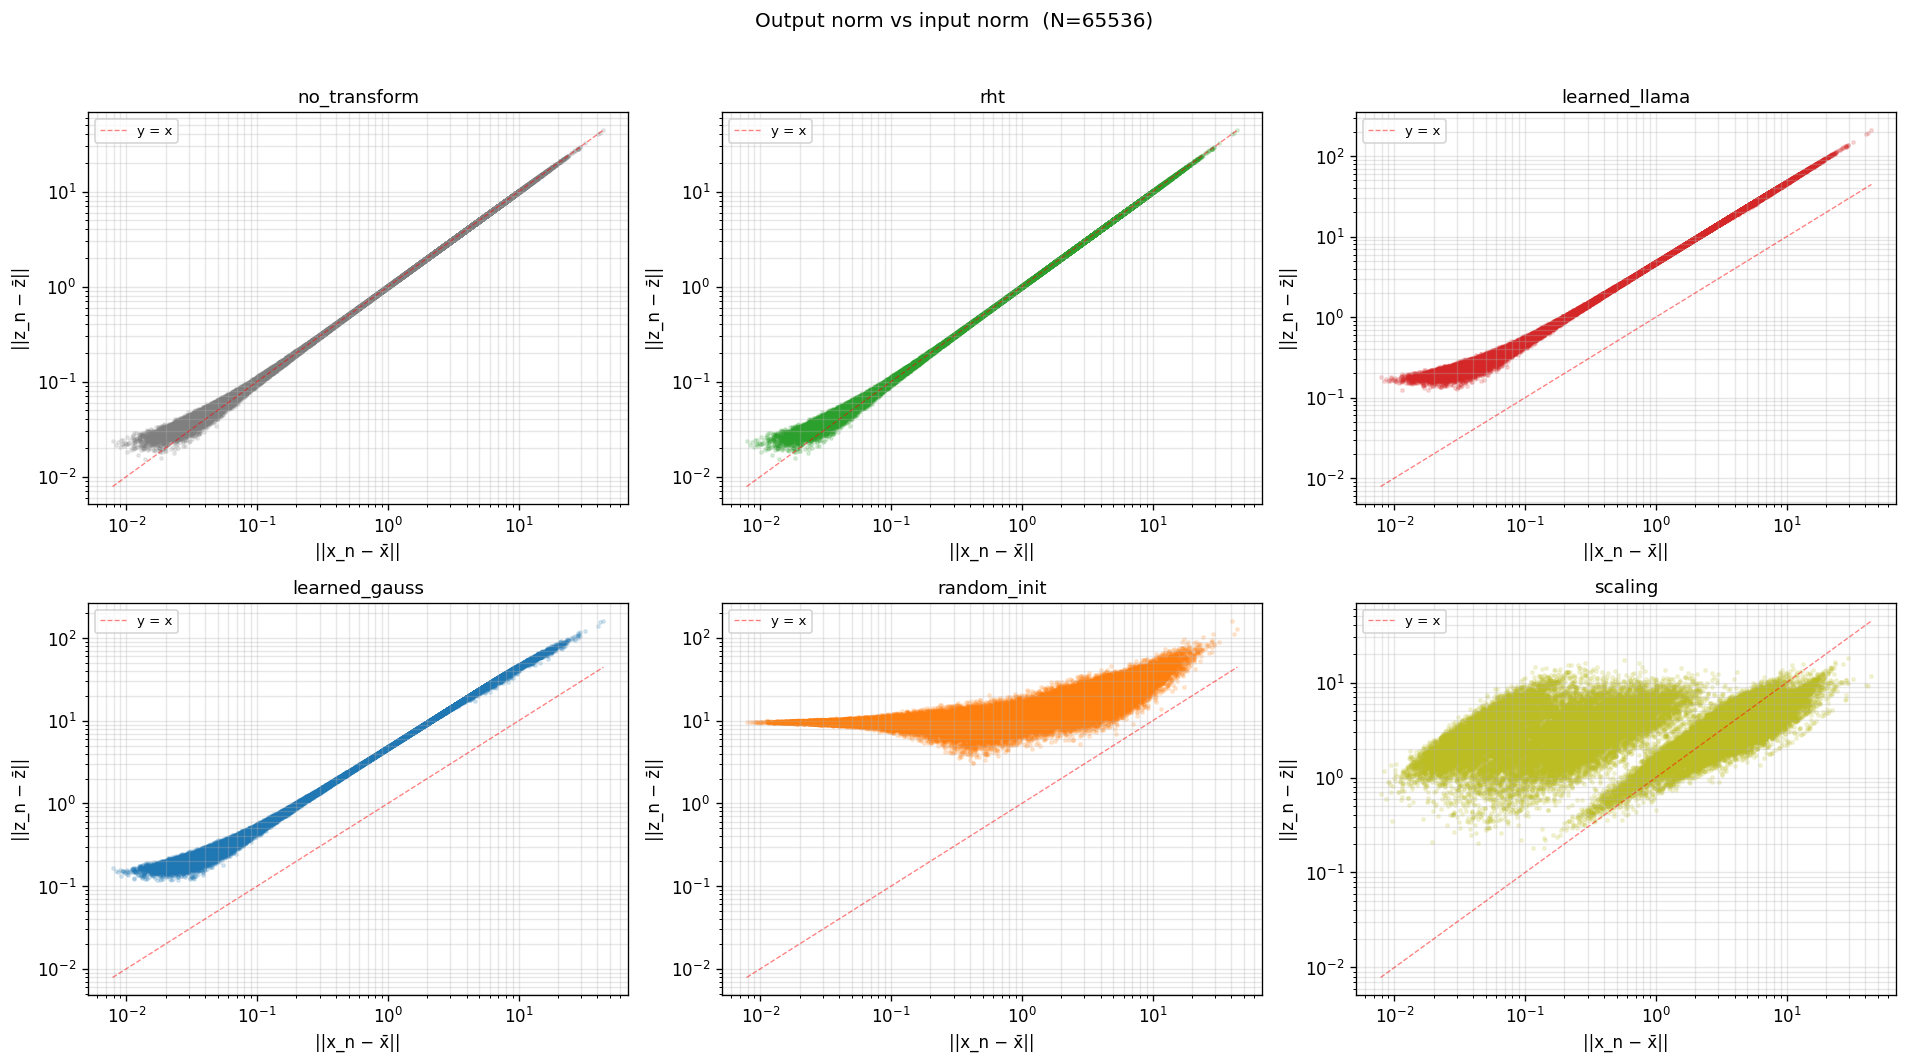

In [16]:
# 8a. Plot — z_size vs x_size, 6 panels (transform), log-log.
fig, axes = plt.subplots(2, 3, figsize=(16, 9), dpi=120)
axes = axes.flatten()
for ax, tname in zip(axes, names_order):
    d = NORM_DATA[tname]
    ax.scatter(d['x_size'], d['z_size'], s=4, alpha=0.15,
               color=color_map.get(tname, 'C0'))
    # reference: y = x (energy preserving)
    xs_ref = np.array([d['x_size'].min(), d['x_size'].max()])
    ax.plot(xs_ref, xs_ref, color='red', ls='--', alpha=0.5, linewidth=0.8, label='y = x')
    ax.set_xlabel('||x_n − x̄||')
    ax.set_ylabel('||z_n − z̄||')
    ax.set_title(tname, fontsize=11)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.grid(True, which='both', alpha=0.3); ax.legend(fontsize=8)
fig.suptitle(f'Output norm vs input norm  (N={N_PLOT})', fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(FIG_DIR / 'fig08_z_vs_x_norm.png'); plt.show()

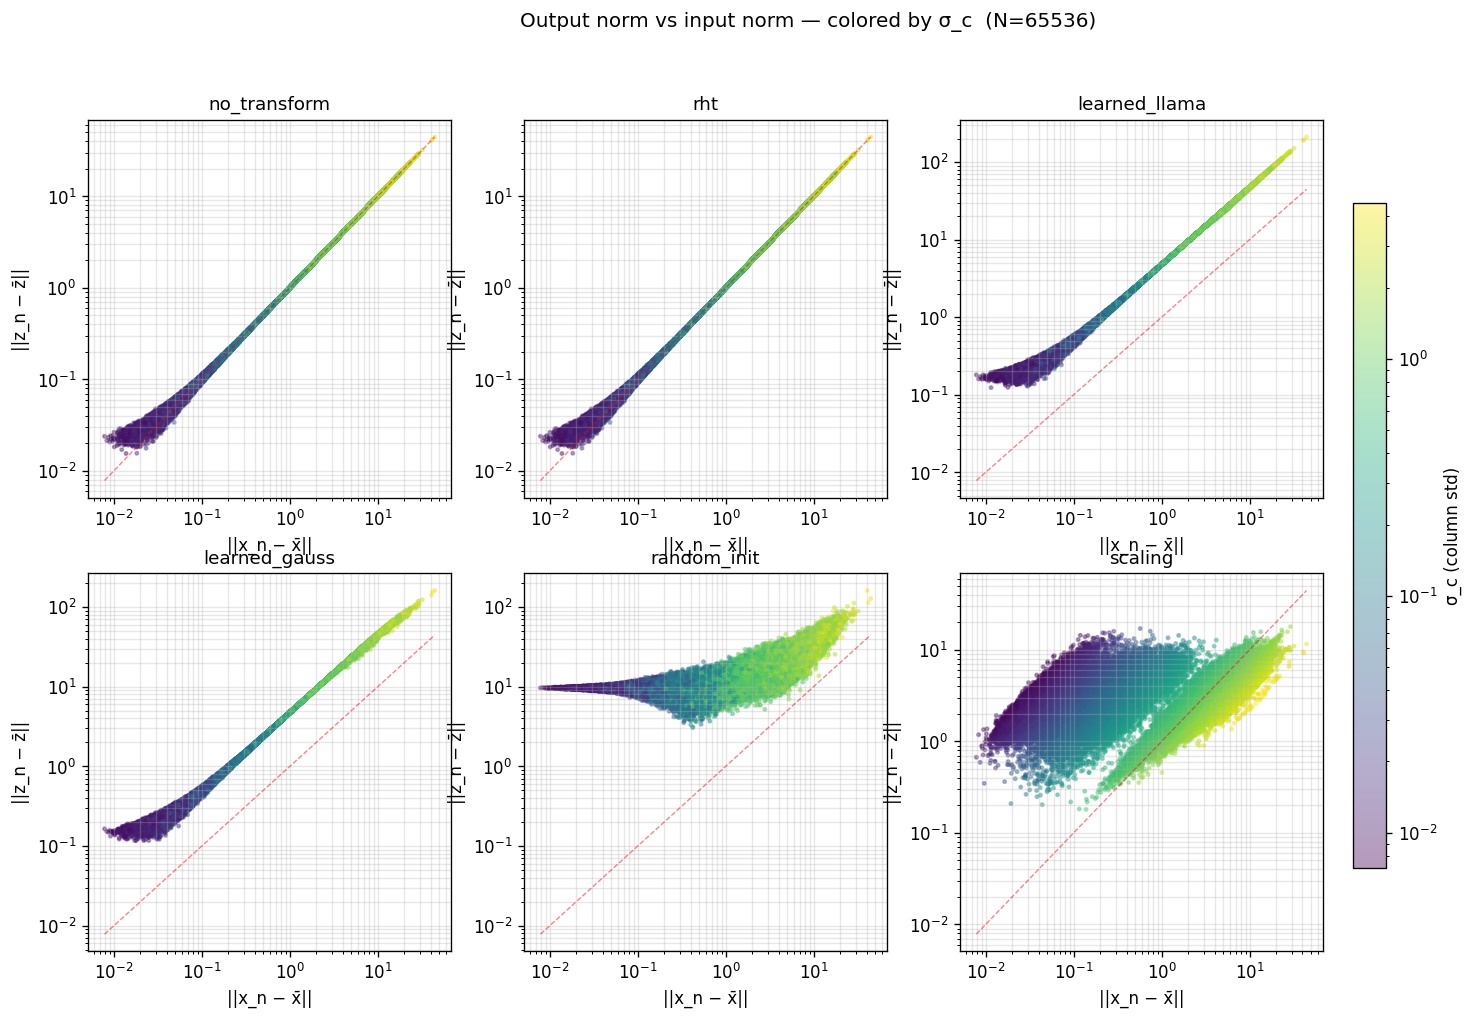

In [17]:
# 8b. Same, colored by σ_c.
import matplotlib.colors as mcolors
fig, axes = plt.subplots(2, 3, figsize=(16, 9), dpi=120)
axes = axes.flatten()
norm_color = mcolors.LogNorm(vmin=float(sigma_col.min()), vmax=float(sigma_col.max()))
for ax, tname in zip(axes, names_order):
    d = NORM_DATA[tname]
    sc = ax.scatter(d['x_size'], d['z_size'], s=4, alpha=0.4,
                    c=d['sigma'], norm=norm_color, cmap='viridis')
    xs_ref = np.array([d['x_size'].min(), d['x_size'].max()])
    ax.plot(xs_ref, xs_ref, color='red', ls='--', alpha=0.5, linewidth=0.8)
    ax.set_xlabel('||x_n − x̄||'); ax.set_ylabel('||z_n − z̄||')
    ax.set_title(tname, fontsize=11)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.grid(True, which='both', alpha=0.3)
plt.colorbar(sc, ax=axes, label='σ_c (column std)', orientation='vertical', pad=0.02, shrink=0.8)
fig.suptitle(f'Output norm vs input norm — colored by σ_c  (N={N_PLOT})', fontsize=12)
fig.savefig(FIG_DIR / 'fig09_z_vs_x_norm_sigma.png', bbox_inches='tight'); plt.show()

## 9. Channel-imbalanced samples — `(4096, 16)` sub-matrix from columns of varying σ

Pick **16 columns of W with diverse σ_c** (evenly-spaced σ-quantiles), form a `(4096, 16)`
sub-matrix.  Each row is now a 16-dim sample whose channel i has scale `σ_i = σ_c[col_i]`,
and σ_i varies up to ~600× across i.

Per-channel σ inequality lets us study **how encoders spread an input outlier on one channel
into the other 15 channels**.

Channel ordering convention (within the 16 selected): sorted by σ_c ascending — so channel 0
has the smallest σ, channel 15 has the largest.

In [ ]:
# 9a. Pick 16 columns of W spanning the σ_c distribution.
N_PICK = 16
sorted_cols = torch.argsort(sigma_col)                                     # ascending σ_c
qpos = torch.linspace(0, len(sorted_cols)-1, N_PICK).round().long()
picked_cols = sorted_cols[qpos]                                            # (16,) global col idx
sigma_pick  = sigma_col[picked_cols]                                       # (16,)

# Sub-matrix: each row is a 16-dim sample
W_sub = W_full[:, picked_cols].to(DEVICE)                                  # (4096, 16)
print(f'picked col indices: {picked_cols.tolist()}')
print(f'σ_pick (per channel, sorted): {[f"{s:.3f}" for s in sigma_pick.tolist()]}')
print(f'σ ratio max/min in selection: {float(sigma_pick.max()/sigma_pick.min()):.1f}')
print(f'W_sub shape={tuple(W_sub.shape)}')

# bar chart of per-channel σ_in
fig, ax = plt.subplots(1, 1, figsize=(8, 3.5), dpi=120)
ax.bar(np.arange(N_PICK), sigma_pick.cpu().numpy(),
       color='tab:blue', edgecolor='black', linewidth=0.6)
ax.set_yscale('log')
ax.set_xticks(np.arange(N_PICK))
ax.set_xlabel('channel index (sorted by σ ascending)')
ax.set_ylabel('σ_in (=σ_c of picked column)')
ax.set_title(f'Per-channel input σ for the selected (4096, 16) sub-matrix')
ax.grid(True, axis='y', which='both', alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig10_channel_sigma_in.png'); plt.show()

In [ ]:
# 9b. Apply each transform to W_sub, measure per-channel output std + mixing matrix.
transform_outputs = {}                                                     # tname -> Z (4096, 16)
for tname in names_order:
    if tname == 'no_transform':
        Z = W_sub.clone()
    elif tname == 'scaling':
        Z = W_sub / sigma_pick.to(DEVICE).unsqueeze(0)                     # (4096, 16)
    else:
        tf = TRANSFORMS[tname]
        with torch.no_grad():
            out = []
            bs = 4096
            for i in range(0, W_sub.shape[0], bs):
                out.append(tf(W_sub[i:i+bs]))
            Z = torch.cat(out, 0)
    transform_outputs[tname] = Z

# Per-channel output std (16 channels)
fig, axes = plt.subplots(2, 3, figsize=(16, 7), dpi=120)
axes = axes.flatten()
sigma_in_np = sigma_pick.cpu().numpy()
for ax, tname in zip(axes, names_order):
    Z = transform_outputs[tname]
    sigma_out = Z.std(dim=0).cpu().numpy()                                 # (16,)
    xs = np.arange(N_PICK)
    width = 0.4
    ax.bar(xs - width/2, sigma_in_np,  width, label='σ_in',  color='tab:blue',  edgecolor='black', linewidth=0.4)
    ax.bar(xs + width/2, sigma_out,    width, label='σ_out', color=color_map.get(tname, 'C0'),
           edgecolor='black', linewidth=0.4)
    ax.set_yscale('log')
    ax.set_xticks(xs)
    ax.set_xlabel('channel index (sorted by σ_in)')
    ax.set_ylabel('std')
    ax.set_title(tname, fontsize=11)
    ax.grid(True, axis='y', which='both', alpha=0.3); ax.legend(fontsize=8)
fig.suptitle(f'Per-channel input/output σ — (4096, 16) sub-matrix with 16 σ-diverse columns',
             fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(FIG_DIR / 'fig11_per_channel_sigma_inout.png'); plt.show()

In [ ]:
# 9c. Mixing matrix: |J_emp[j,i]| (16×16) — column i = where channel i goes; row j = which inputs feed channel j.
# Computed as Σ_zx · Σ_xx⁻¹ on the (4096, 16) sub-matrix.
@torch.no_grad()
def emp_jacobian(X, Z, eps=1e-9):
    Xc = X - X.mean(0, keepdim=True); Zc = Z - Z.mean(0, keepdim=True)
    n  = X.shape[0]
    Sxx = Xc.T @ Xc / (n - 1) + eps * torch.eye(X.shape[1], device=X.device, dtype=X.dtype)
    Sxz = Xc.T @ Zc / (n - 1)
    return torch.linalg.solve(Sxx, Sxz).T

J_pick = {}
for tname in names_order:
    Z = transform_outputs[tname]
    J_pick[tname] = emp_jacobian(W_sub, Z).cpu()                           # (16, 16)

fig, axes = plt.subplots(2, 3, figsize=(15, 8), dpi=120)
axes = axes.flatten()
for ax, tname in zip(axes, names_order):
    A = J_pick[tname].abs().numpy()
    vmax = float(A.max())
    im = ax.imshow(A, cmap='viridis', vmin=0, vmax=vmax)
    ax.set_xlabel('input ch (σ ↑)')
    ax.set_ylabel('output ch')
    ax.set_title(tname, fontsize=11)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle('|J_emp| mixing matrices — (4096, 16) sub-matrix with σ-diverse columns', fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(FIG_DIR / 'fig12_mixing_matrix.png'); plt.show()

In [ ]:
# 9d. Outlier spreading — find rows where ONE input channel has the dominant value.
# For each row, compute m2med = max(|x|)/median(|x|).  Sort top 8 by m2med.
abs_W = W_sub.abs()
m2med_row = (abs_W.max(dim=-1).values / abs_W.median(dim=-1).values.clamp_min(1e-12)).cpu().numpy()
top_idx = np.argsort(m2med_row)[-8:][::-1]                                 # top 8 outlier rows
print(f'Top-8 row indices by m2med: {top_idx.tolist()}')
print(f'  m2med values: {m2med_row[top_idx].round(2).tolist()}')

# For each top row + each transform: bar plot of |x| (input) and |z| (output) across 16 channels.
fig, axes = plt.subplots(len(top_idx), len(names_order), figsize=(3*len(names_order), 1.5*len(top_idx)),
                         dpi=110, sharex='col')
for r, row_idx in enumerate(top_idx):
    x = W_sub[row_idx].cpu().numpy()
    for c, tname in enumerate(names_order):
        z = transform_outputs[tname][row_idx].cpu().numpy()
        ax = axes[r, c]
        xs = np.arange(N_PICK)
        # plot |x| and |z| side by side
        width = 0.4
        ax.bar(xs - width/2, np.abs(x), width, color='tab:blue', alpha=0.7, label='|x|')
        ax.bar(xs + width/2, np.abs(z), width, color=color_map.get(tname, 'C0'), alpha=0.7, label='|z|')
        ax.set_yscale('log')
        if r == 0: ax.set_title(tname, fontsize=9)
        if c == 0:
            ax.set_ylabel(f'row {row_idx}\nm2m={m2med_row[row_idx]:.1f}', fontsize=8)
        if r == len(top_idx)-1: ax.set_xlabel('channel', fontsize=8)
        ax.grid(True, axis='y', which='both', alpha=0.3)
        ax.tick_params(labelsize=7)
        if r == 0 and c == len(names_order)-1: ax.legend(fontsize=6, loc='upper right')
fig.suptitle('Outlier spreading: |x| vs |z| per channel (top-8 rows by m2med ratio)', fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(FIG_DIR / 'fig13_outlier_spreading.png'); plt.show()

In [ ]:
# 9e. Quantitative outlier-spreading metric: per row, m2med(|x|) vs m2med(|z|).
# Lower m2med(z) ⇒ encoder spreads the outlier across channels; m2med(z) ≈ m2med(x) ⇒ no spreading.
fig, axes = plt.subplots(2, 3, figsize=(16, 9), dpi=120)
axes = axes.flatten()
for ax, tname in zip(axes, names_order):
    Z = transform_outputs[tname]
    abs_Z = Z.abs()
    m2med_z = (abs_Z.max(dim=-1).values / abs_Z.median(dim=-1).values.clamp_min(1e-12)).cpu().numpy()
    ax.scatter(m2med_row, m2med_z, s=4, alpha=0.4, color=color_map.get(tname, 'C0'))
    lim = [min(m2med_row.min(), m2med_z.min()), max(m2med_row.max(), m2med_z.max())]
    ax.plot(lim, lim, color='red', ls='--', alpha=0.5, linewidth=0.8, label='y = x (no spread)')
    ax.set_xlabel('m2med(|x|) — input outlier strength')
    ax.set_ylabel('m2med(|z|) — output outlier strength')
    ax.set_title(tname, fontsize=11)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.grid(True, which='both', alpha=0.3); ax.legend(fontsize=8)
fig.suptitle('Outlier strength: input vs output  (below y=x line ⇒ encoder spreads outliers)',
             fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(FIG_DIR / 'fig14_outlier_m2med_scatter.png'); plt.show()

# Summary stats
print(f"{'transform':<14} {'m2med(x) mean':>14} {'m2med(z) mean':>14} {'ratio z/x':>10}")
for tname in names_order:
    Z = transform_outputs[tname]
    abs_Z = Z.abs()
    m2med_z = (abs_Z.max(dim=-1).values / abs_Z.median(dim=-1).values.clamp_min(1e-12)).cpu().numpy()
    ratio = m2med_z.mean() / m2med_row.mean()
    print(f'{tname:<14}  {m2med_row.mean():>13.3f}  {m2med_z.mean():>13.3f}  {ratio:>10.3f}')